# Insula functional NMF (corrected waveform analysis)

Unsupervised discovery of **three insula waveform classes** (`k=3` exploratory) from Hammers AIC/PIC electrodes.

**Principles (no anatomical label leakage):**
1. Fit NMF on the **stimulus epoch only** (temporal shape after rectify + L2 normalization).
2. Name components from waveform (`sensory_transient` / `intermediate` / `sustained_ramping`), not from AIC/PIC.
3. Use delay / go / response only as **held-out** characterizations; Hammers labels only for spatial validation.

Outputs go under `results/nmf/k3` and `img/nmf_k3` so the main k=2 tables are not overwritten.

Analysis logic lives in `src/nmf/` (tested).


In [1]:
%matplotlib inline

import sys
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import Image, display

ROOT = Path('..').resolve()
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

from src.nmf.waveform_analysis import (
    CLUSTER_ORDER,
    PHASE_WINDOWS,
    TASKS,
    discover_paths,
    fit_nmf_grid,
    held_out_contrasts,
    load_hga_rows,
    orient_components,
    plot_model_selection,
    plot_spatial,
    plot_waveforms,
    prepare_shape_matrix,
    restrict_windows,
    stimulus_matrix,
    summarize_held_out,
    write_component_table,
)

cm = 1 / 2.54
plt.rcParams['svg.fonttype'] = 'none'
fontsize = 7

from src.paths import RESULTS_ROOT, nmf_results_dir
from src.paths import img_dir, save_svg

K = 3
OUTPUT_DIR = nmf_results_dir() / f'k{K}'
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
IMG_DIR = img_dir(f'nmf_k{K}')

EXCLUDE_SUBJECTS = {'D0121'}
K_MAX = 6
N_INIT = 20
MAX_ITER = 5000
RANDOM_STATE = 42


## 1. Stimulus discovery matrix

Electrodes: Hammers pure `AIC`/`PIC`, `mix=False`, `label!=0`, `Repeat` + `sound`, bilateral. Stimulus epoch must cover ≥95% of time samples.


In [2]:
all_paths = discover_paths(RESULTS_ROOT, TASKS)
print(f'HGA CSV files: {len(all_paths)}')

stimulus_rows = load_hga_rows(
    all_paths,
    phases={'stimulus'},
    exclude_subjects=EXCLUDE_SUBJECTS,
)
stimulus_rows = restrict_windows(stimulus_rows)
raw_matrix, metadata = stimulus_matrix(stimulus_rows)
X, keep = prepare_shape_matrix(raw_matrix.to_numpy())
raw_matrix = raw_matrix.iloc[np.flatnonzero(keep)]
metadata = metadata.iloc[np.flatnonzero(keep)]

print(
    f'Discovery matrix: {X.shape[0]} electrodes × {X.shape[1]} time points | '
    f'AIC={metadata["roi"].eq("AIC").sum()} PIC={metadata["roi"].eq("PIC").sum()} | '
    f'subjects={metadata["subject"].nunique()}'
)

HGA CSV files: 892


/hpc/group/coganlab/nanlinshi/insula-functional/src/nmf/waveform_analysis.py:216: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  & ~frame["mix"].fillna(False).astype(bool)
/hpc/group/coganlab/nanlinshi/insula-functional/src/nmf/waveform_analysis.py:216: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  & ~frame["mix"].fillna(False).astype(bool)
/hpc/group/coganlab/nanlinshi/insula-functional/src/nmf/waveform_analysis.py:216: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result

  read 100/234 files


/hpc/group/coganlab/nanlinshi/insula-functional/src/nmf/waveform_analysis.py:216: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  & ~frame["mix"].fillna(False).astype(bool)
/hpc/group/coganlab/nanlinshi/insula-functional/src/nmf/waveform_analysis.py:216: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  & ~frame["mix"].fillna(False).astype(bool)
/hpc/group/coganlab/nanlinshi/insula-functional/src/nmf/waveform_analysis.py:216: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result

  read 200/234 files


/hpc/group/coganlab/nanlinshi/insula-functional/src/nmf/waveform_analysis.py:216: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  & ~frame["mix"].fillna(False).astype(bool)
/hpc/group/coganlab/nanlinshi/insula-functional/src/nmf/waveform_analysis.py:216: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  & ~frame["mix"].fillna(False).astype(bool)
/hpc/group/coganlab/nanlinshi/insula-functional/src/nmf/waveform_analysis.py:208: DtypeWarning: Columns (34) have mixed types. Specify dtype option on import or set low_memory=False.
  frame = pd.read_csv(path, usecols

Discovery matrix: 280 electrodes × 191 time points | AIC=180 PIC=100 | subjects=64


/hpc/group/coganlab/nanlinshi/insula-functional/src/nmf/waveform_analysis.py:216: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  & ~frame["mix"].fillna(False).astype(bool)


## 2. Model selection (k = 1…6)

Compare reconstruction error, cosine silhouette, and stability (ARI across inits). Dashed line marks the selected `K` (currently 3).


  k=1: counts=[280] sil=nan stability=nan
  k=2: counts=[135, 145] sil=0.208 stability=1.000
  k=3: counts=[131, 102, 47] sil=0.215 stability=1.000
  k=4: counts=[57, 92, 42, 89] sil=0.142 stability=1.000
  k=5: counts=[55, 56, 38, 95, 36] sil=0.113 stability=1.000
  k=6: counts=[57, 61, 39, 42, 36, 45] sil=0.102 stability=1.000


,k,reconstruction_error,explained_energy,silhouette_cosine,stability_ari,min_cluster_n,cluster_counts,converged_runs,n_init
0,1,12.0812,0.4787,NaN,NaN,280,280,17,20
1,2,10.9173,0.5743,0.2081,1.0,135,135;145,20,20
2,3,10.2267,0.6265,0.2154,1.0,47,131;102;47,20,20
3,4,9.7628,0.6596,0.1420,1.0,42,57;92;42;89,20,20
4,5,9.3435,0.6882,0.1129,1.0,36,55;56;38;95;36,20,20
5,6,8.9782,0.7121,0.1024,1.0,36,57;61;39;42;36;45,20,20


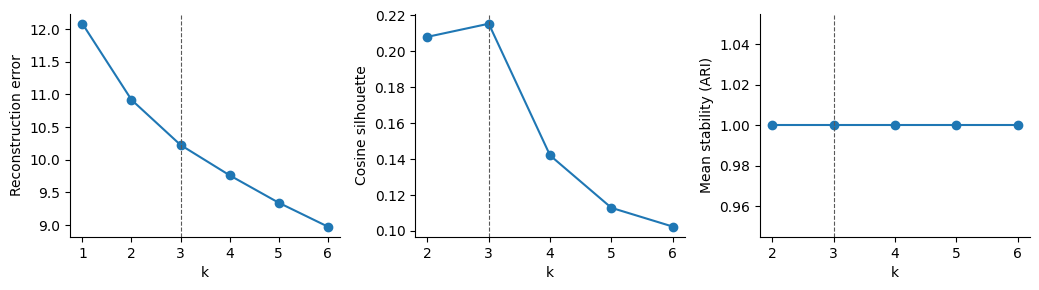

In [3]:
metrics, fits = fit_nmf_grid(
    X,
    k_max=K_MAX,
    n_init=N_INIT,
    random_state=RANDOM_STATE,
    max_iter=MAX_ITER,
)
display(metrics.round(4))

fig_k = plot_model_selection(metrics, selected_k=K)
fig_k.savefig(OUTPUT_DIR / 'model_selection.png', dpi=240, bbox_inches='tight')
save_svg(fig_k, IMG_DIR / 'model_selection')
plt.show()


## 3. k = 3 functional clusters + Hammers validation

Hard assignment uses **normalized** NMF loadings. Anatomy (AIC/PIC) is shown only after clustering (exploratory crosstab; no binary AIC↔function agreement test for k=3).


Component naming (early−late of H):
  component 0 → sustained_ramping
  component 1 → sensory_transient
  component 2 → intermediate
Counts: {'sustained_ramping': 131, 'sensory_transient': 102, 'intermediate': 47}
Functional cluster × Hammers atlas:


roi,AIC,PIC
functional_cluster,,
sustained_ramping,112,19
intermediate,31,16
sensory_transient,37,65


,k,n_electrodes,n_subjects,n_sustained_ramping,n_intermediate,n_sensory_transient
0,3,280,64,131,47,102


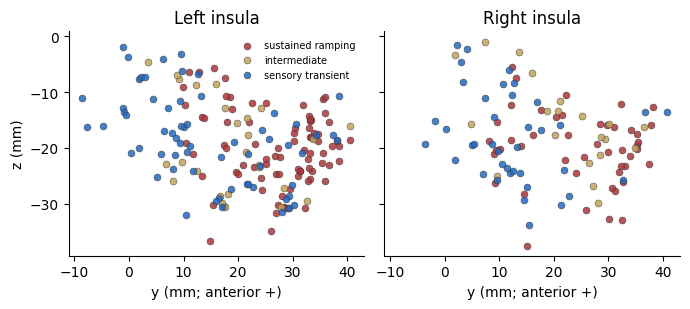

In [4]:
if K not in fits:
    raise ValueError(f'Need fits[{K}] from model selection')

fit = fits[K]
W = np.asarray(fit['W'])
H = np.asarray(fit['H'])
component = np.asarray(fit['labels'], dtype=int)
times = raw_matrix.columns.to_numpy(float)
component_names = orient_components(H, times)
functional_cluster = np.array([component_names[c] for c in component])

assignments = metadata.reset_index().copy()
assignments['component'] = component
assignments['functional_cluster'] = functional_cluster
for comp_idx, name in component_names.items():
    assignments[f'loading_{name}'] = W[:, comp_idx]
assignments['dominance'] = W.max(axis=1) / np.maximum(W.sum(axis=1), 1e-12)

cluster_index = [name for name in CLUSTER_ORDER if name in set(functional_cluster)]
crosstab = pd.crosstab(assignments['functional_cluster'], assignments['roi']).reindex(
    index=cluster_index,
    columns=['AIC', 'PIC'],
    fill_value=0,
)

spatial_stats = pd.DataFrame([{
    'k': K,
    'n_electrodes': len(assignments),
    'n_subjects': assignments['subject'].nunique(),
    **{
        f'n_{name}': int((assignments['functional_cluster'] == name).sum())
        for name in cluster_index
    },
}])

print('Component naming (early−late of H):')
for idx, name in sorted(component_names.items()):
    print(f'  component {idx} → {name}')
print('Counts:', assignments['functional_cluster'].value_counts().to_dict())
print('Functional cluster × Hammers atlas:')
display(crosstab)
display(spatial_stats)

fig_sp = plot_spatial(assignments)
fig_sp.savefig(OUTPUT_DIR / 'spatial_yz.png', dpi=240, bbox_inches='tight')
save_svg(fig_sp, IMG_DIR / 'spatial_yz')
plt.show()


## 4. Held-out waveforms (delay / go / response)

Subject-balanced means ± 95% CI across electrodes. Stimulus was used for clustering and is not re-tested here.


/hpc/group/coganlab/nanlinshi/insula-functional/src/nmf/waveform_analysis.py:216: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  & ~frame["mix"].fillna(False).astype(bool)
/hpc/group/coganlab/nanlinshi/insula-functional/src/nmf/waveform_analysis.py:216: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  & ~frame["mix"].fillna(False).astype(bool)
/hpc/group/coganlab/nanlinshi/insula-functional/src/nmf/waveform_analysis.py:216: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result

  read 100/892 files


/hpc/group/coganlab/nanlinshi/insula-functional/src/nmf/waveform_analysis.py:216: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  & ~frame["mix"].fillna(False).astype(bool)
/hpc/group/coganlab/nanlinshi/insula-functional/src/nmf/waveform_analysis.py:216: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  & ~frame["mix"].fillna(False).astype(bool)
/hpc/group/coganlab/nanlinshi/insula-functional/src/nmf/waveform_analysis.py:216: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result

  read 200/892 files


/hpc/group/coganlab/nanlinshi/insula-functional/src/nmf/waveform_analysis.py:216: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  & ~frame["mix"].fillna(False).astype(bool)
/hpc/group/coganlab/nanlinshi/insula-functional/src/nmf/waveform_analysis.py:216: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  & ~frame["mix"].fillna(False).astype(bool)
/hpc/group/coganlab/nanlinshi/insula-functional/src/nmf/waveform_analysis.py:216: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result

...

/hpc/group/coganlab/nanlinshi/insula-functional/src/nmf/waveform_analysis.py:216: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  & ~frame["mix"].fillna(False).astype(bool)
/hpc/group/coganlab/nanlinshi/insula-functional/src/nmf/waveform_analysis.py:216: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  & ~frame["mix"].fillna(False).astype(bool)
/hpc/group/coganlab/nanlinshi/insula-functional/src/nmf/waveform_analysis.py:216: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result

  read 700/892 files


/hpc/group/coganlab/nanlinshi/insula-functional/src/nmf/waveform_analysis.py:216: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  & ~frame["mix"].fillna(False).astype(bool)
/hpc/group/coganlab/nanlinshi/insula-functional/src/nmf/waveform_analysis.py:216: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  & ~frame["mix"].fillna(False).astype(bool)
/hpc/group/coganlab/nanlinshi/insula-functional/src/nmf/waveform_analysis.py:216: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result

  read 800/892 files


/hpc/group/coganlab/nanlinshi/insula-functional/src/nmf/waveform_analysis.py:216: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  & ~frame["mix"].fillna(False).astype(bool)
/hpc/group/coganlab/nanlinshi/insula-functional/src/nmf/waveform_analysis.py:216: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  & ~frame["mix"].fillna(False).astype(bool)
/hpc/group/coganlab/nanlinshi/insula-functional/src/nmf/waveform_analysis.py:216: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result

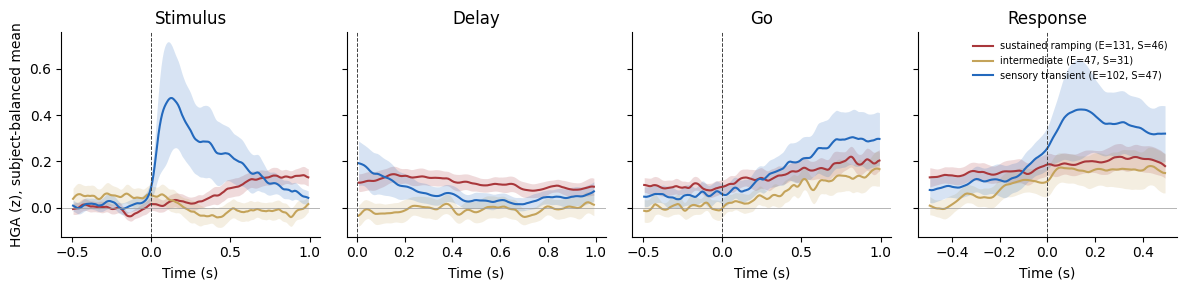

,functional_cluster,phase,n_channels,n_subjects
0,intermediate,delay,43,30
1,intermediate,go,43,30
2,intermediate,response,47,31
3,intermediate,stimulus,47,31
4,sensory_transient,delay,101,46
5,sensory_transient,go,101,46
6,sensory_transient,response,102,47
7,sensory_transient,stimulus,102,47
8,sustained_ramping,delay,128,46
9,sustained_ramping,go,128,46


,contrast,test_type,n_subjects,mean_predicted_difference,wilcoxon_one_sided_p
0,delay_plateau,paired_between_cluster,33,0.068363,0.008908
1,response_peak,paired_between_cluster,33,0.169096,0.021202
2,sustained_delay_above_zero,one_sample_within_cluster,46,0.110353,0.000000
3,sensory_response_post_vs_pre,paired_within_cluster,47,0.264901,0.000001


In [5]:
held_out_rows = load_hga_rows(
    all_paths,
    phases=set(PHASE_WINDOWS),
    exclude_subjects=EXCLUDE_SUBJECTS,
    channels=set(assignments['channel']),
)
waveform_summary, coverage = summarize_held_out(held_out_rows, assignments)

# Held-out contrasts still compare sustained vs sensory when both exist;
# intermediate is shown in waveforms only.
contrasts = held_out_contrasts(held_out_rows, assignments)

fig_wf = plot_waveforms(waveform_summary, coverage)
fig_wf.savefig(OUTPUT_DIR / 'cluster_waveforms.png', dpi=240, bbox_inches='tight')
save_svg(fig_wf, IMG_DIR / 'cluster_waveforms')
plt.show()

display(coverage)
display(
    contrasts[
        ['contrast', 'test_type', 'n_subjects', 'mean_predicted_difference', 'wilcoxon_one_sided_p']
    ].round(6)
)


## 5. Surface brain map (compute node)

Requires `ieeg` + off-screen Brain rendering. On login nodes this may fail; run on a compute node or submit `scripts/slurm/nmf_corrected_brain_render.sh`.


Using notebook 3d backend.
Reading labels from parcellation...
   read 75 labels from /cwork/ns458/ECoG_Recon/cvs_avg35_inMNI152/label/lh.aparc.a2009s.annot
   read 75 labels from /cwork/ns458/ECoG_Recon/cvs_avg35_inMNI152/label/rh.aparc.a2009s.annot


2026-07-21 13:31:32.668 (   2.387s) [    7F3E886ED740]vtkXOpenGLRenderWindow.:1416  WARN| bad X server connection. DISPLAY=
libEGL warning: egl: failed to create dri2 screen
libEGL warning: egl: failed to create dri2 screen
libEGL warning: failed to open /dev/dri/card8: Permission denied

2026-07-21 13:31:32.732 (   2.450s) [    7F3E886ED740] vtkEGLRenderWindow.cxx:353   WARN| vtkEGLRenderWindow (0x7d60eb0): EGL device index: 0 could not be initialized. Trying other devices...
libEGL warning: egl: failed to create dri2 screen
libEGL warning: egl: failed to create dri2 screen
libEGL warning: failed to open /dev/dri/card7: Permission denied

libEGL warning: egl: failed to create dri2 screen
libEGL warning: egl: failed to create dri2 screen
libEGL warning: failed to open /dev/dri/card6: Permission denied

libEGL warning: egl: failed to create dri2 screen
libEGL warning: egl: failed to create dri2 screen
libEGL warning: failed to open /dev/dri/card5: Permission denied

libEGL warning: egl:

Wrote /hpc/group/coganlab/nanlinshi/insula-functional/results/nmf/k3/brain_functional_clusters.png


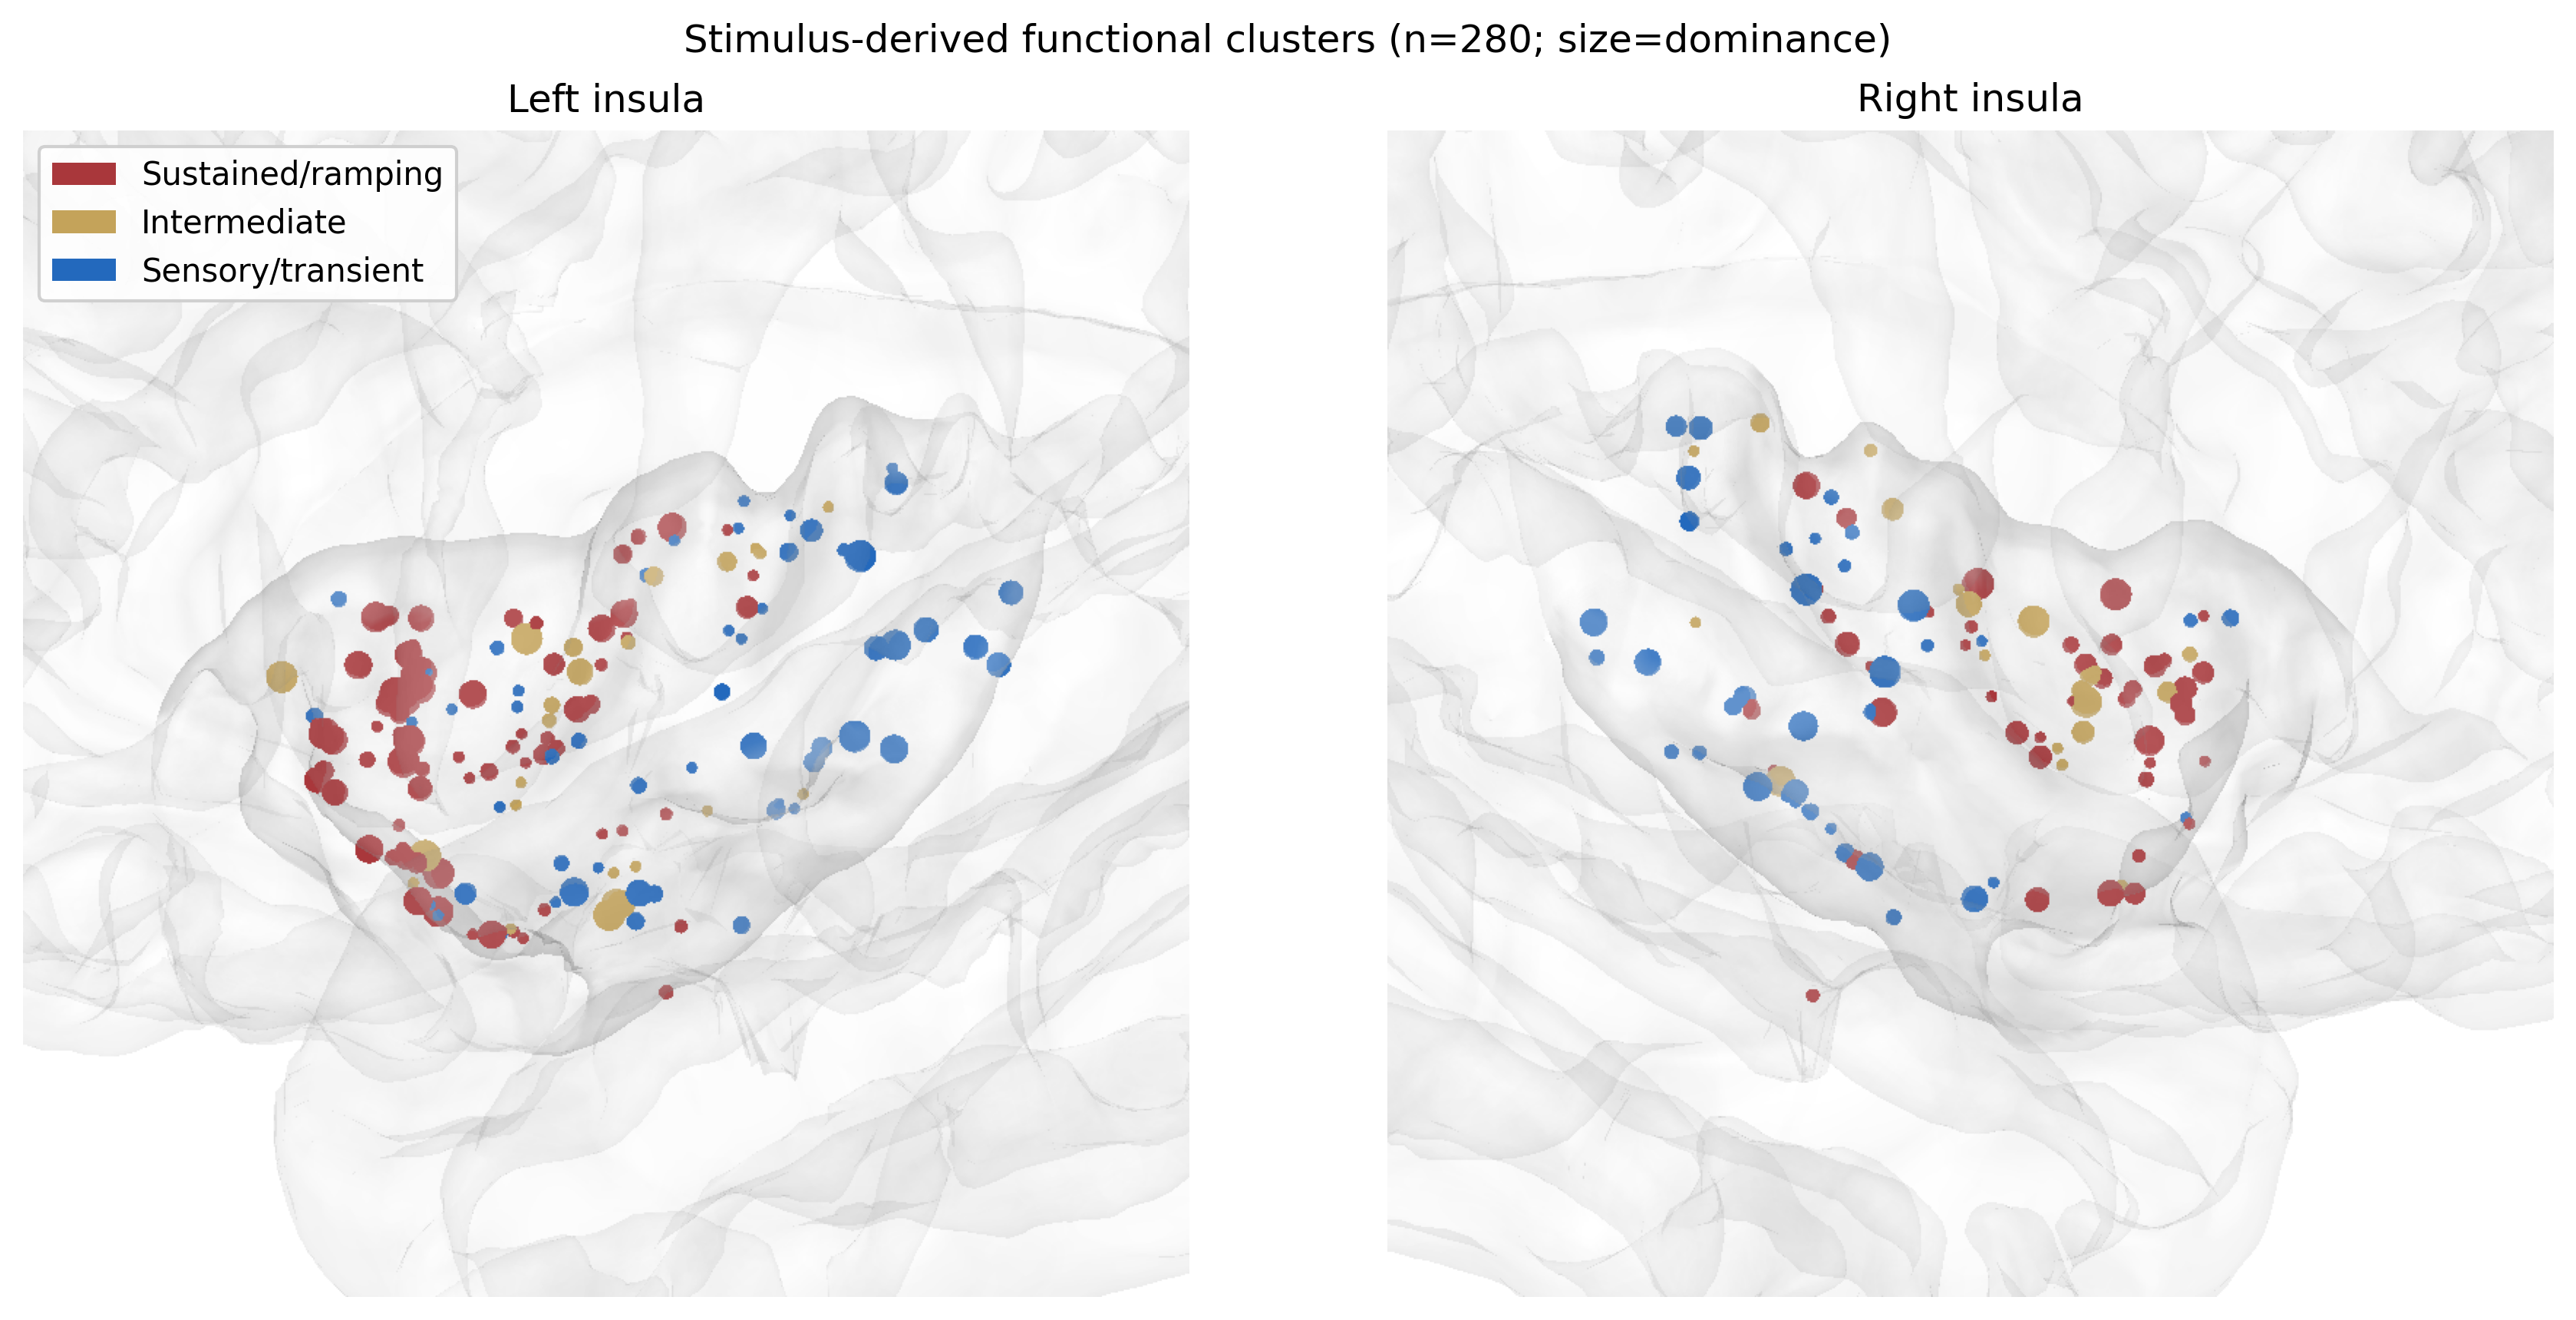

Wrote k=3 tables and figures to /hpc/group/coganlab/nanlinshi/insula-functional/results/nmf/k3 and /hpc/group/coganlab/nanlinshi/insula-functional/img/nmf_k3


In [6]:
assignments.to_csv(OUTPUT_DIR / 'channel_assignments.csv', index=False)
metrics.to_csv(OUTPUT_DIR / 'model_selection_metrics.csv', index=False)
write_component_table(H, times, OUTPUT_DIR / 'stimulus_components.csv')
crosstab.to_csv(OUTPUT_DIR / 'functional_by_hammers.csv')
spatial_stats.to_csv(OUTPUT_DIR / 'spatial_validation.csv', index=False)
waveform_summary.to_csv(OUTPUT_DIR / 'held_out_waveform_summary.csv', index=False)
coverage.to_csv(OUTPUT_DIR / 'held_out_coverage.csv', index=False)
contrasts.to_csv(OUTPUT_DIR / 'held_out_contrasts.csv', index=False)

brain_png = OUTPUT_DIR / 'brain_functional_clusters.png'
try:
    from src.nmf.render_brain import render
    import argparse
    args = argparse.Namespace(
        assignments=OUTPUT_DIR / 'channel_assignments.csv',
        output=brain_png,
        recon_dir=Path('/cwork/ns458/ECoG_Recon/'),
        fs_subject='cvs_avg35_inMNI152',
        size_min=8.0,
        size_max=22.0,
    )
    render(args)
    display(Image(filename=str(brain_png)))
except Exception as exc:
    print(f'Brain render skipped: {exc}')
    print('Run: python -m src.nmf.run_render_brain --assignments', OUTPUT_DIR / 'channel_assignments.csv')

print(f'Wrote k={K} tables and figures to {OUTPUT_DIR} and {IMG_DIR}')


## Interpretation notes (k=3 exploratory)

- Components named by stimulus early−late of **H**: highest → sensory_transient (blue), lowest → sustained_ramping (red), middle → intermediate (gold).
- Expect the third class to be smaller and more mixed in time/space than the two dominant motifs.
- Main manuscript analysis remains k=2 (`results/nmf/`); this notebook writes exploratory k=3 under `results/nmf/k3`.


## 6. Per-phase NMF inspection (exploratory)

Same corrected pipeline (**rectify + L2 shape NMF**), but discovery is run **separately** on each phase (`stimulus`, `delay`, `go`, `response`). Component names still use early-minus-late of **H** (shape labels, not anatomy — especially for go/response).

**This is exploratory inspection only** — it does not replace the main stimulus-discovery membership in `results/nmf/` (k=2) or `results/nmf/k3/`.

Full figures (H curves, spatial YZ, held-out waveforms across all four epochs, summary + `H_overview`) are generated by:

```bash
python scripts/plot_nmf_phase_compare.py   # k=2 and k=3
# or: sbatch scripts/slurm/nmf_phase_compare.sh
```

Outputs: `results/nmf/phase_compare/k{2,3}/` and `img/nmf_phase_compare/k{2,3}/` (`components_*.svg`, `spatial_yz_*.svg`, `waveforms_*.svg`, `phase_nmf_summary.csv`, `H_overview.svg`).

The cells below reproduce a quick summary inline; prefer the CLI outputs for publication-style SVGs.

In [7]:
from src.nmf.waveform_analysis import FUNCTION_COLORS, ordered_clusters, phase_matrix
from sklearn.metrics import adjusted_rand_score

PHASE_COMPARE_DIR = OUTPUT_DIR / 'phase_compare'
PHASE_COMPARE_DIR.mkdir(parents=True, exist_ok=True)

try:
    _ = held_out_rows
except NameError:
    held_out_rows = load_hga_rows(
        all_paths,
        phases=set(PHASE_WINDOWS),
        exclude_subjects=EXCLUDE_SUBJECTS,
    )

all_phase_rows = restrict_windows(held_out_rows)

try:
    stimulus_ref = assignments.set_index('channel')['functional_cluster']
except NameError:
    stimulus_ref = None

phase_results = {}
summary_rows = []

for phase in PHASE_WINDOWS:
    raw_mat, meta = phase_matrix(all_phase_rows, phase)
    X_phase, keep = prepare_shape_matrix(raw_mat.to_numpy())
    raw_mat = raw_mat.iloc[np.flatnonzero(keep)]
    meta = meta.iloc[np.flatnonzero(keep)]

    metrics_p, fits_p = fit_nmf_grid(
        X_phase,
        k_max=K,
        n_init=N_INIT,
        random_state=RANDOM_STATE,
        max_iter=MAX_ITER,
    )
    fit_p = fits_p[K]
    W_p = np.asarray(fit_p['W'])
    H_p = np.asarray(fit_p['H'])
    labels_p = np.asarray(fit_p['labels'], dtype=int)
    times_p = raw_mat.columns.to_numpy(float)
    names_p = orient_components(H_p, times_p)
    cluster_p = np.array([names_p[c] for c in labels_p])

    assign_p = meta.reset_index().copy()
    assign_p['component'] = labels_p
    assign_p['functional_cluster'] = cluster_p
    for idx, name in names_p.items():
        assign_p[f'loading_{name}'] = W_p[:, idx]

    cluster_index = ordered_clusters(cluster_p)
    crosstab_p = pd.crosstab(assign_p['functional_cluster'], assign_p['roi']).reindex(
        index=cluster_index,
        columns=['AIC', 'PIC'],
        fill_value=0,
    )
    sil = float(metrics_p.loc[metrics_p['k'] == K, 'silhouette_cosine'].iloc[0])

    ari = np.nan
    if stimulus_ref is not None:
        shared = assign_p.set_index('channel').index.intersection(stimulus_ref.index)
        if len(shared) >= 5:
            ari = adjusted_rand_score(
                stimulus_ref.loc[shared].to_numpy(),
                assign_p.set_index('channel').loc[shared, 'functional_cluster'].to_numpy(),
            )

    phase_results[phase] = {
        'assignments': assign_p,
        'crosstab': crosstab_p,
        'silhouette': sil,
        'ari_vs_stimulus': ari,
        'n': len(assign_p),
    }
    row = {
        'phase': phase,
        'n_electrodes': len(assign_p),
        'n_AIC': int((assign_p['roi'] == 'AIC').sum()),
        'n_PIC': int((assign_p['roi'] == 'PIC').sum()),
        'silhouette_cosine': sil,
        'ari_vs_stimulus_clusters': ari,
    }
    for name in CLUSTER_ORDER:
        if name in crosstab_p.index:
            row[f'{name}_AIC'] = int(crosstab_p.loc[name, 'AIC'])
            row[f'{name}_PIC'] = int(crosstab_p.loc[name, 'PIC'])
    summary_rows.append(row)
    print(f'{phase:10s} n={len(assign_p):3d} sil={sil:.3f} ARI_vs_stim={ari:.3f}')
    print(crosstab_p)
    print()

phase_summary = pd.DataFrame(summary_rows)
display(phase_summary.round(4))
phase_summary.to_csv(PHASE_COMPARE_DIR / 'phase_nmf_summary.csv', index=False)


  k=1: counts=[280] sil=nan stability=nan
  k=2: counts=[135, 145] sil=0.208 stability=1.000
  k=3: counts=[131, 102, 47] sil=0.215 stability=1.000
stimulus   n=280 sil=0.215 ARI_vs_stim=1.000
roi                 AIC  PIC
functional_cluster          
sustained_ramping   112   19
intermediate         31   16
sensory_transient    37   65

  k=1: counts=[269] sil=nan stability=nan
  k=2: counts=[173, 96] sil=0.183 stability=1.000
  k=3: counts=[142, 56, 71] sil=0.193 stability=1.000
delay      n=269 sil=0.193 ARI_vs_stim=0.073
roi                 AIC  PIC
functional_cluster          
sustained_ramping    43   28
intermediate        102   40
sensory_transient    30   26

  k=1: counts=[271] sil=nan stability=nan
  k=2: counts=[163, 108] sil=0.263 stability=1.000
  k=3: counts=[123, 102, 46] sil=0.180 stability=1.000
go         n=271 sil=0.180 ARI_vs_stim=0.018
roi                 AIC  PIC
functional_cluster          
sustained_ramping    84   39
intermediate         26   20
sensory_transie

,phase,n_electrodes,n_AIC,n_PIC,silhouette_cosine,ari_vs_stimulus_clusters,sustained_ramping_AIC,sustained_ramping_PIC,intermediate_AIC,intermediate_PIC,sensory_transient_AIC,sensory_transient_PIC
0,stimulus,280,180,100,0.2154,1.0000,112,19,31,16,37,65
1,delay,269,175,94,0.1930,0.0727,43,28,102,40,30,26
2,go,271,176,95,0.1801,0.0178,84,39,26,20,66,36
3,response,279,180,99,0.1972,-0.0067,82,47,53,35,45,17


In [8]:
# Four YZ spatial maps (Left / Right), one per discovery phase — same style as main analysis.
for phase, result in phase_results.items():
    assign_p = result['assignments']
    clusters = ordered_clusters(assign_p['functional_cluster'])
    fig, axes = plt.subplots(1, 2, figsize=(7.0, 3.2), sharex=True, sharey=True)
    for axis, (hemi, title) in zip(axes, (('L', 'Left'), ('R', 'Right'))):
        side = assign_p.loc[assign_p['hemi'].eq(hemi)]
        for functional_cluster in clusters:
            points = side.loc[side['functional_cluster'].eq(functional_cluster)]
            axis.scatter(
                points['y'], points['z'], s=25,
                color=FUNCTION_COLORS.get(functional_cluster, '0.35'),
                edgecolor='0.2', linewidth=0.35, alpha=0.85,
                label=functional_cluster.replace('_', ' '),
            )
        axis.set_title(f'{title} insula')
        axis.set_xlabel('y (mm; anterior +)')
        axis.spines[['top', 'right']].set_visible(False)
    axes[0].set_ylabel('z (mm)')
    axes[0].legend(frameon=False, fontsize=7)
    fig.suptitle(
        f'NMF k={K} on {phase}  '
        f'(n={result["n"]}, sil={result["silhouette"]:.2f}, '
        f'ARI vs stim={result["ari_vs_stimulus"]:.2f})',
        fontsize=9,
    )
    fig.tight_layout()
    out = PHASE_COMPARE_DIR / f'spatial_yz_{phase}.png'
    # fig.savefig(out, dpi=240, bbox_inches='tight')
    plt.show()
    print(f'Saved {out}')

print(f'All phase-compare figures → {PHASE_COMPARE_DIR}')


Saved /hpc/group/coganlab/nanlinshi/insula-functional/results/nmf/k3/phase_compare/spatial_yz_stimulus.png
Saved /hpc/group/coganlab/nanlinshi/insula-functional/results/nmf/k3/phase_compare/spatial_yz_delay.png
Saved /hpc/group/coganlab/nanlinshi/insula-functional/results/nmf/k3/phase_compare/spatial_yz_go.png
Saved /hpc/group/coganlab/nanlinshi/insula-functional/results/nmf/k3/phase_compare/spatial_yz_response.png
All phase-compare figures → /hpc/group/coganlab/nanlinshi/insula-functional/results/nmf/k3/phase_compare
